In [4]:
# imports
# !pip install graphviz
from graphviz import Digraph
import math
import random

# given a graph, return a set of nodes and edges



In [5]:
# Value class

# what do we actually want out of this thing again??


class Value:
    def __init__(self, d, _children=(), lb=''):
        self._backward = lambda: None
        self._prev = set(_children) # done for efficiency (??? but you iterate over it so really who gaf) 
        self.data = d
        self.grad = 0.0
        self._op = ''
        self.label = lb

    def __add__(self, other):
        if not isinstance(other, Value):
            other = Value(other)
        out = Value(self.data + other.data, (self, other))
        def _backwards():
            # if f = a + b, df/da = 1 and df/db = 1, and * out.grad because chain rule (d(something else)/da = d(something else)/df * df/da)
            # += and not = because what if f = a + a? want df/da to be 2, not 1, and in the non-duplicate case += only happens once so equivalent to =
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backwards
        out._op = '+'
        return out

    def __neg__(self):
        out = Value(self.data *-1, (self,))
        def _backwards():
            # if f = a - b, df/da = 1 and df/db = - 1
            self.grad += -1.0 * out.grad
        out._backward = _backwards
        out._op = '-'
        return out

    def __sub__(self, other):
        return self + other.__neg__()

    def __mul__(self, other):
        if not isinstance(other, Value):
            other = Value(other)
        out = Value(self.data * other.data, (self, other))
        def _backwards():
            # if f = a*b, df/da = b and df/db = a
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backwards
        out._op = '*'
        return out
    
    # when we try to do 2.__add__(a) it will freak out and check if a has rmul to call so this is for that
    def __rmul__(self, other):
        return self.__mul__(other)
    
    def __radd__(self, other): # other + self
        return self.__add__(other)

    def tanh(self):
        x = self.data
        invtan = (math.exp(2*x) - 1)/(math.exp(2*x) + 1) # shoutout wikipedia!!
        out = Value(invtan, (self, ))
        out._op = 'tanh' # oops
        def _backward():
            self.grad += (1 - invtan**2) * out.grad

        out._backward = _backward
        return out
    
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ))
        out._op = 'exp'
        def _backwards():
            self.grad += out.data * out.grad # derivative of e^x is just e^x so data = grad

        out._backward = _backwards
        return out

    def backwards(self):
        def toposort(g):
            # how do you toposort again??
            # start by dfs-ing
            # this will visit all deepest nodes first i think??
            # so we like that
            # "reverse dfs postorder" hmmm
            # so what this means is if i visit some node, i need to visit all its children first
            # and eventually once ive visited all its
            ordered = []
            seen = set()
            def visit(v):
                if v not in seen:
                    seen.add(v)
                    for child in v._prev:
                        visit(child)
                    ordered.append(v)
            visit(g)
            return ordered
        
        ts = toposort(self)
        self.grad = 1.0
        for value in reversed(ts):
            value._backward()
    
    def __pow__(self, other):
        assert isinstance(other, (int, float))
        out = Value(self.data ** other, (self,))
    
        def _backwards():
            self.grad += (other * self.data ** (other - 1)) * out.grad
        
        out._backward = _backwards; 
        out._op = f'**{other}'
        return out
    
    def relu(self):
        # derivative of relu is just 0 if before the bend, 1 if after
        out = Value(0.0 if self.data < 0 else self.data, (self,))

        def _backwards():
            self.grad += (out.data > 0) * out.grad

        out._backward = _backwards; out._op = 'ReLU'
        return out
    
    def zero_grad(self):
        # just set every previous value's .grad to 0
        zeroed = set()
        def zero_all_prev(v):
            if v not in zeroed:
                v.grad = 0
                zeroed.add(v)
                for c in v._prev:
                    zero_all_prev(c)
        zero_all_prev(self)

    def __truediv__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        return self * other**-1
    
    def __rsub__(self, other):     return (-self) + other      # for  2 - a
    def __rtruediv__(self, other): return (self**-1) * other    # for  2 / a


In [6]:
# trying to visualize the graph using just the graphviz docs lmao

def get_V_and_E_from_value_obj(v):
    # wait gang this is just bf/dfs?? no one gaf?? just add yourself and then add your children
    V = set()
    E = set()
    
    def add_node_and_kids(vertex):
        if vertex not in V:
            V.add(vertex)
            for kid in vertex._prev:
                E.add((kid, vertex))
                add_node_and_kids(kid)
    
    add_node_and_kids(v)
    return V, E

# this part i did refer to the draw_dot function but only for syntax!
def draw_expr_graph(value):
    g = Digraph(format='svg', graph_attr={'rankdir': 'LR'})
    vertices, edges = get_V_and_E_from_value_obj(value)
    for vertex in vertices:
        uid = str(id(vertex))
        g.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (vertex.label, vertex.data, vertex.grad), shape='record')
        if vertex._op:
            g.node(name=uid + vertex._op, label=vertex._op)
            g.edge(uid + vertex._op, uid)
    
    for source, target in edges:
        if target._op:
            g.edge(str(id(source)), str(id(target)) + target._op)
    
    return g
        



In [7]:
a = Value(0.2, lb='a')
b = Value(0.3, lb='b')
c = a+b; c.label='c'
d = Value(0.5, lb='d')
f = d*c; f.label='f'
g = Value(0.1, lb='g')
exponentiated_g = g.exp()
h = f + exponentiated_g
j = h.tanh()


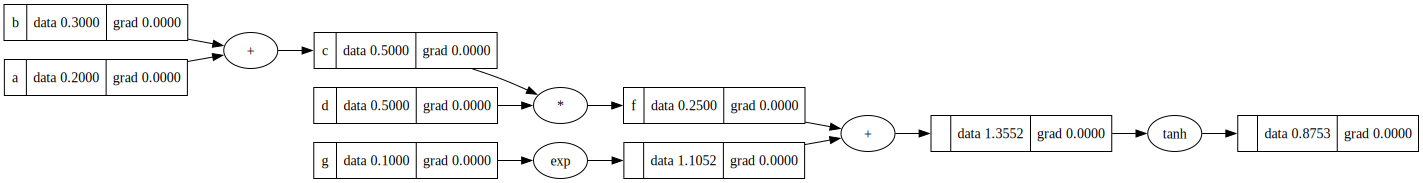

In [8]:
draw_expr_graph(j)

In [9]:
j.backwards()
h.grad

0.2339054347206918

In [10]:
# now we compare to torch to see if all the grads look right!
def compare_to_torch(out_val):

    # jk this will be tabled for later i DO want to come back to it but i think this is some expression parsing business that is a fun detour for rn
    pass
    # start by performing the same toposort operation, get V & E
    # now for each node in topological order, create it in pytorch?? "create a new tensor with this value"
    # now the edges?
        # for (source, target) in edges:
            # wait lowk dont we also need to go thru edges in "topological order"? i THINK this is what topo gives us but should check
            # ok so "in topological order", we say if the target edge has a + in the id, then we know we are waiting to add it
                # is this a pop it off the stack mmt?!?!?
                # like you start by putting this thing onto the stack, with a key of the operation and a value of the operand?
                # and then NEXT TIME YOU SEE THAT SAME EDGE REFERENCED, you add it to the list of operands keyed by that operation???
                # ok and so if you go through and do all these right? and thats E time to go through because hashmap O(1) and guaranteed no repeat edges so we never have to search thru the list
                # you can switch case and
                # ...oh shit hang on
                # so we start with first expression? and we say yo
    # and now for the edges, figure out how to correctly 
    # and for each edge create it in pytorch also? like do the edge from a to + and from b to +? need to be clear on what the edges actually are??

In [11]:
# cool now we toposort this thing and call backwards everywhere! initialize grad of the final function to 1




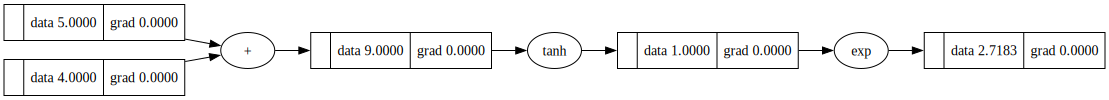

In [12]:
a = Value(4.0)
b = Value(5.0)
c = a + b
d = c.tanh()
e = d.exp()
draw_expr_graph(e)


In [13]:
# "gradient checks"
def grad_check(f, x_val, h=1e-5):
    # using backwards
    x = Value(x_val)
    y = f(x)
    y.backwards()
    analytic = x.grad
    # the f(x+h) way
    numeric = (f(Value(x_val + h)).data - f(Value(x_val - h)).data) / (2*h)
    print(analytic, " vs ", numeric)
    assert abs(analytic - numeric) < 1e-4, f"{analytic} vs {numeric}"

In [14]:
for x_val in [-50, -3, -0.5, -1e-3, 0.0, 1e-3, 0.5, 3, 50]:
    grad_check(lambda x: x.tanh(), x_val)
print("tanh works!")

for x_val in [-10, -1, 0.0, 1, 10]:
    grad_check(lambda x: x.exp(), x_val)
print("exp works!")

0.0  vs  0.0
0.00986603716543999  vs  0.009866037170569442
0.7864477329659274  vs  0.7864477329505569
0.9999990000006667  vs  0.9999989999672528
1.0  vs  0.9999999999648378
0.9999990000006667  vs  0.99999899997108
0.7864477329659274  vs  0.786447732956108
0.009866037165440211  vs  0.009866037165018327
0.0  vs  0.0
tanh works!
4.5399929762484854e-05  vs  4.539992976151192e-05
0.36787944117144233  vs  0.3678794411765551
1.0  vs  1.0000000000121023
2.718281828459045  vs  2.718281828517632
22026.465794806718  vs  22026.46579426073
exp works!


In [153]:
# just following along w/ my goat andrej
class Neuron:
    def __init__(self, nin, nonlin=True):
        # make nin weights and one bias 
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(0.0)
        self.nonlin = nonlin
    def __call__(self, x):
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b) # expression is theta_0 + theta_1(x_1) + theta_2(x_2)...
        return act.relu() if self.nonlin else act # and then nonlinearity this thing! chose relu from UDL
    def parameters(self):
        return self.w + [self.b] # just package all the tunable things together
 
class Layer:
    def __init__(self, nin, nout, **kw):
        # keep track of all the neurons in a layer, each with nin inputs :x:>o 
        self.neurons = [Neuron(nin, **kw) for _ in range(nout)]
    def __call__(self, x):
        outs = [n(x) for n in self.neurons] # get the outputs for each of the neurons
        return outs[0] if len(outs) == 1 else outs # return an array if more than 1 val, if one just unbox it for convenience
    def parameters(self):
        return [p for n in self.neurons for p in n.parameters()] # all the tunable things for the whole layer!
 
class MLP:
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1], nonlin=(i!= len(nouts) - 1)) for i in range(len(nouts))] # wow now we stack layers!!
    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]
    def zero_grad(self):
        for p in self.parameters():
            p.grad = 0.0

In [154]:
# hmm why is this thing not converging as per the test?
random.seed(42)
model = MLP(3, [4, 4, 1])
xs = [[2.0, 3.0, -1.0], [3.0, -1.0, 0.5], [0.5, 1.0, 1.0], [1.0, 1.0, -1.0]]
ys = [1.0, -1.0, -1.0, 1.0]

In [155]:
[model(xs[i]).data for i in range(len(xs))]
# we want these guys to be getting closer and closer to -1 and 1

[0.0, 0.21700743528948885, 0.1541238442751902, 0.038518461148052005]

In [156]:
preds = [model(training_ex) for training_ex in xs]
# this is "run a forward pass on each example, then store in this array"

# initially this sum thing was erroring because sum() returns an int not a Value object, so initialized start so that overloaded + is used


total_loss = sum(((p - y) ** 2 for p, y in zip(preds, ys)), start=Value(0.0)) 
# sum up all the squared differences between the predicted and actual
total_loss.data

4.737555695027552

In [147]:
model.zero_grad()
total_loss.backwards()
print("BEFORE UPDATE:", [model(xs[i]).data for i in range(len(xs))])
print("there are a total of", len(model.parameters()), "params")
for p in model.parameters():
    #print("p.data is", p.data)
    #print("p.grad is", p.grad)
    p.data -= 0.0001 * p.grad
    #print("updated p.data", p.data)

BEFORE UPDATE: [0.0, 0.21325326265622702, 0.15159877638945898, 0.03771654710147673]
there are a total of 41 params


In [177]:

for _ in range(500):
    # compute forward pass & print loss
    preds = [model(training_ex) for training_ex in xs]
    total_loss = sum(((p - y) ** 2 for p, y in zip(preds, ys)), start=Value(0.0)) 
    print(total_loss.data)
    # update weights!
    model.zero_grad()
    total_loss.backwards()
    for p in model.parameters():
        #print("p.data is", p.data)
        #print("p.grad is", p.grad)
        p.data -= 0.0001 * p.grad
    
    # this is "run a forward pass on each example, then store in this array"

    # initially this sum thing was erroring because sum() returns an int not a Value object, so initialized start so that overloaded + is us    # sum up all the squared differences between the predicted and actual
    
    #print("updated p.data", p.data)

0.01796186506922298
0.017953053472274508
0.017944245989261098
0.017935442618259398
0.017926643357350152
0.017917848204617864
0.01790905715815076
0.017900270216040796
0.017891487376383446
0.017882708637277783
0.01787393399682633
0.017865163453134904
0.017856438596503533
0.017848028906540744
0.017839270356701412
0.017830515897950924
0.017821765528375135
0.017813019246063752
0.017804277049110303
0.017795538935612195
0.017786804903670305
0.017778074951389236
0.01776934907687707
0.01776062727824524
0.017751909553608714
0.017743195901085626
0.017734853517102585
0.017726172401669606
0.017717470671578417
0.017708773007952126
0.017700079408889124
0.017691389872491584
0.017682704396865433
0.017674022980120364
0.0176653456203694
0.017656672315729288
0.017648003064320163
0.017639337864265567
0.017630676713692246
0.017622321007580953
0.017613755833841227
0.01760510653921561
0.017596461288450896
0.01758782007965424
0.017579182910936433
0.01757054978041223
0.01756192068619988
0.017553295626421245
0.0